<a href="https://colab.research.google.com/github/ElPatudo/App-Salud-Digital-3/blob/main/GAFNet_Maiz_Deteccion_Colab_CORREGIDO_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install "ultralytics==8.4.42" "opencv-python-headless>=4.8" pandas matplotlib pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.0 MB/s eta 0:00:00


In [ ]:
import os
import sys
import json
import math
import shutil
import zipfile
import requests
import pathlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from IPython.display import display
from ultralytics import YOLO
from ultralytics.nn import tasks


class GSConv(nn.Module):
    # Grouped Spatial Convolution del proyecto GAF-Net.
    def __init__(self, c1, c2=None, k=3, s=1):
        super().__init__()
        if c2 is None:
            c2 = c1

        c_ = c2 // 2

        self.cv1 = nn.Conv2d(c1, c_, 1, s)
        self.dw = nn.Conv2d(
            c_,
            c_,
            k,
            1,
            padding=k // 2,
            groups=c_
        )
        self.bn = nn.BatchNorm2d(c_)
        self.act = nn.SiLU()

    def forward(self, x):
        x1 = self.cv1(x)
        x2 = self.act(self.bn(self.dw(x1)))

        y = torch.cat((x1, x2), dim=1)

        b, c, h, w = y.shape

        y = (
            y.reshape(b, 2, c // 2, h, w)
             .permute(0, 2, 1, 3, 4)
             .reshape(b, c, h, w)
        )

        return y


class FASFF(nn.Module):
    # Feature-Adaptive Spatial Feature Fusion del proyecto.
    def __init__(self, c1, c2=256, level=0):
        super().__init__()

        if isinstance(c1, int):
            c1 = [c1, c1, c1]

        self.level = level
        self.c2 = c2

        self.reduce = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ci, c2, 1, 1, bias=False),
                nn.BatchNorm2d(c2),
                nn.SiLU(),
            )
            for ci in c1
        ])

        self.weight_layers = nn.ModuleList([
            nn.Conv2d(c2, 1, 1, 1, 0)
            for _ in range(3)
        ])

    def _resize_to(self, x, size):
        if x.shape[-2:] == size:
            return x

        if x.shape[-2] > size[0] or x.shape[-1] > size[1]:
            return F.adaptive_avg_pool2d(x, size)

        return F.interpolate(
            x,
            size=size,
            mode="nearest"
        )

    def forward(self, x):
        assert isinstance(x, (list, tuple)) and len(x) == 3

        target_size = x[self.level].shape[-2:]

        feats = [
            self.reduce[i](
                self._resize_to(x[i], target_size)
            )
            for i in range(3)
        ]

        weights = torch.stack([
            self.weight_layers[i](feats[i])
            for i in range(3)
        ], dim=0)

        weights = torch.softmax(weights, dim=0)

        fused = (
            weights[0] * feats[0]
            + weights[1] * feats[1]
            + weights[2] * feats[2]
        )

        return fused


def _get_out_channels(module):
    if isinstance(module, GSConv):
        return module.cv1.out_channels * 2

    if isinstance(module, nn.Sequential) and len(module) > 0:
        return _get_out_channels(module[-1])

    if hasattr(module, "cv2"):
        return _get_out_channels(module.cv2)

    if (
        hasattr(module, "conv")
        and isinstance(module.conv, nn.Conv2d)
    ):
        return module.conv.out_channels

    for child in reversed(list(module.children())):
        result = _get_out_channels(child)
        if result is not None:
            return result

    return None


# Registrar módulos para el cargador de Ultralytics.
tasks.GSConv = GSConv
tasks.FASFF = FASFF

# También exponerlos explícitamente en __main__, necesario para
# algunos checkpoints de PyTorch serializados desde notebooks.
import __main__
__main__.GSConv = GSConv
__main__.FASFF = FASFF

try:
    torch.serialization.add_safe_globals([GSConv, FASFF])
except Exception:
    pass


# Monkey-patch utilizado por el notebook original de GAF-Net.
if not hasattr(tasks, "_original_parse_model"):
    tasks._original_parse_model = tasks.parse_model


def patched_parse_model(d, ch, verbose=True):
    from copy import deepcopy

    d2 = deepcopy(d)

    fasff_info = []
    gsconv_info = []

    for section in ("backbone", "head"):
        for i, layer in enumerate(d2.get(section, [])):
            f, n, m_name, args = layer

            if m_name == "FASFF":
                fasff_info.append(
                    (section, i, f, args, n)
                )
                d2[section][i] = [
                    -1,
                    1,
                    "Conv",
                    [args[0], 1, 1]
                ]

            elif m_name == "GSConv":
                gsconv_info.append(
                    (section, i, f, args, n)
                )
                d2[section][i] = [
                    f,
                    n,
                    "Conv",
                    args
                ]

    model, save = tasks._original_parse_model(
        d2,
        ch,
        verbose
    )

    if not gsconv_info and not fasff_info:
        return model, save

    backbone_len = len(d.get("backbone", []))

    for section, idx, from_val, orig_args, n in gsconv_info:
        global_idx = (
            idx
            if section == "backbone"
            else backbone_len + idx
        )

        dummy = model[global_idx]

        if isinstance(dummy, nn.Sequential):
            conv_mod = dummy[0]
        else:
            conv_mod = dummy

        c1_actual = conv_mod.conv.in_channels
        c2_actual = conv_mod.conv.out_channels

        k = orig_args[1] if len(orig_args) > 1 else 3
        s = orig_args[2] if len(orig_args) > 2 else 1

        n_actual = (
            len(dummy)
            if isinstance(dummy, nn.Sequential)
            else 1
        )

        if n_actual > 1:
            gs = nn.Sequential(*(
                GSConv(
                    c1_actual if j == 0 else c2_actual,
                    c2_actual,
                    k,
                    s if j == 0 else 1
                )
                for j in range(n_actual)
            ))
        else:
            gs = GSConv(
                c1_actual,
                c2_actual,
                k,
                s
            )

        gs.i = global_idx
        gs.f = from_val
        gs.type = "GSConv"
        gs.np = sum(
            p.numel()
            for p in gs.parameters()
        )

        model[global_idx] = gs

    for section, idx, from_val, args, n in fasff_info:
        global_idx = (
            idx
            if section == "backbone"
            else backbone_len + idx
        )

        if isinstance(from_val, list):
            input_chs = [
                _get_out_channels(model[fi])
                for fi in from_val
            ]
        else:
            input_chs = [
                _get_out_channels(model[from_val])
            ] * 3

        actual_c2 = _get_out_channels(
            model[global_idx]
        )

        level = (
            args[1]
            if len(args) > 1
            else 0
        )

        fasff = FASFF(
            input_chs,
            actual_c2,
            level
        )

        fasff.i = global_idx
        fasff.f = from_val
        fasff.type = "FASFF"
        fasff.np = sum(
            p.numel()
            for p in fasff.parameters()
        )

        model[global_idx] = fasff

        if isinstance(from_val, list):
            for fidx in from_val:
                real = (
                    fidx
                    if fidx >= 0
                    else global_idx + fidx
                )

                if real not in save:
                    save.append(real)

    return model, save


tasks.parse_model = patched_parse_model

print("✅ Módulos personalizados de GAF-Net registrados.")
print("PyTorch:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Módulos personalizados de GAF-Net registrados.
PyTorch: 2.11.0+cu130


## 3. Descargar automáticamente los pesos públicos `best.pt`

El archivo publicado por los autores está comprimido como `best.pt.zip`.

In [ ]:
WEIGHTS_URL = (
    "https://github.com/AnanyaGubba/"
    "GAF-Net-Multi-Disease-Corn-Leaf-Detection/"
    "raw/refs/heads/main/best.pt.zip"
)

MODEL_DIR = pathlib.Path("/content/gafnet_maize")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = MODEL_DIR / "best.pt.zip"
BEST_PT = MODEL_DIR / "best.pt"

if not ZIP_PATH.exists():
    print("Descargando checkpoint...")
    response = requests.get(
        WEIGHTS_URL,
        timeout=120
    )
    response.raise_for_status()
    ZIP_PATH.write_bytes(response.content)

print(
    "Archivo descargado:",
    ZIP_PATH,
    f"({ZIP_PATH.stat().st_size / (1024**2):.2f} MB)"
)

# ------------------------------------------------------------
# IMPORTANTE:
# Un checkpoint .pt de PyTorch moderno ES internamente un archivo ZIP.
# En este repositorio el archivo fue publicado como "best.pt.zip".
#
# Por eso NO debemos asumir que contiene otro .pt dentro.
# Primero inspeccionamos su estructura interna:
# ------------------------------------------------------------

def looks_like_torch_checkpoint_zip(path):
    """
    Detecta si un ZIP parece ser directamente un checkpoint
    serializado por torch.save().
    """
    if not zipfile.is_zipfile(path):
        return False

    try:
        with zipfile.ZipFile(path, "r") as zf:
            names = zf.namelist()

        # Los checkpoints torch suelen contener data.pkl dentro
        # de una carpeta raíz como 'archive/' o 'best/'.
        has_data_pkl = any(
            name.endswith("/data.pkl") or name == "data.pkl"
            for name in names
        )

        has_tensor_data = any(
            "/data/" in name
            for name in names
        )

        return has_data_pkl and has_tensor_data

    except Exception:
        return False


if looks_like_torch_checkpoint_zip(ZIP_PATH):
    print(
        "✅ El archivo descargado es directamente un checkpoint "
        "PyTorch empaquetado internamente como ZIP."
    )
    print(
        "   No se descomprimirá. Se copiará como best.pt."
    )

    shutil.copy2(ZIP_PATH, BEST_PT)

else:
    print(
        "ℹ️ El archivo parece ser un ZIP contenedor. "
        "Buscando un checkpoint .pt dentro..."
    )

    EXTRACT_DIR = MODEL_DIR / "weights"
    EXTRACT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    if not zipfile.is_zipfile(ZIP_PATH):
        raise RuntimeError(
            "El archivo descargado no es un ZIP válido "
            "ni un checkpoint PyTorch reconocible."
        )

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        print("Contenido del ZIP:")
        for name in zf.namelist()[:30]:
            print(" -", name)

        zf.extractall(EXTRACT_DIR)

    pt_files = list(
        EXTRACT_DIR.rglob("*.pt")
    )

    if pt_files:
        shutil.copy2(
            pt_files[0],
            BEST_PT
        )
    else:
        # Último intento robusto:
        # buscar archivos extraídos sin extensión que internamente
        # parezcan checkpoints torch.
        candidates = [
            p for p in EXTRACT_DIR.rglob("*")
            if p.is_file()
        ]

        torch_candidates = [
            p for p in candidates
            if looks_like_torch_checkpoint_zip(p)
        ]

        if torch_candidates:
            largest = max(
                torch_candidates,
                key=lambda p: p.stat().st_size
            )
            shutil.copy2(
                largest,
                BEST_PT
            )
        else:
            print("\nArchivos extraídos:")
            for p in candidates[:50]:
                print(
                    f" - {p.relative_to(EXTRACT_DIR)} "
                    f"({p.stat().st_size / 1024:.1f} KB)"
                )

            raise FileNotFoundError(
                "No se pudo identificar automáticamente "
                "el checkpoint del modelo."
            )

if not BEST_PT.exists():
    raise FileNotFoundError(
        "No se logró preparar /content/gafnet_maize/best.pt"
    )

print()
print("✅ Checkpoint preparado correctamente:")
print(BEST_PT)
print(
    f"Tamaño final: "
    f"{BEST_PT.stat().st_size / (1024**2):.2f} MB"
)

# Comprobación adicional del formato interno.
if zipfile.is_zipfile(BEST_PT):
    with zipfile.ZipFile(BEST_PT, "r") as zf:
        internal_names = zf.namelist()
        print("\nPrimeros archivos internos del checkpoint:")
        for name in internal_names[:10]:
            print(" -", name)

print("\n✅ Listo para cargar con Ultralytics.")

Descargando checkpoint...
Archivo descargado: /content/gafnet_maize/best.pt.zip (5.97 MB)
✅ El archivo descargado es directamente un checkpoint PyTorch empaquetado internamente como ZIP.
   No se descomprimirá. Se copiará como best.pt.

✅ Checkpoint preparado correctamente:
/content/gafnet_maize/best.pt
Tamaño final: 5.97 MB

Primeros archivos internos del checkpoint:
 - best/data.pkl
 - best/.format_version
 - best/.storage_alignment
 - best/byteorder
 - best/data/0
 - best/data/1
 - best/data/2
 - best/data/3
 - best/data/4
 - best/data/5

✅ Listo para cargar con Ultralytics.


## 4. Cargar el modelo entrenado

Si todo está correcto, deben aparecer cuatro clases:

`blight`, `common_rust`, `gray_spot`, `health`.

In [ ]:
print("Cargando GAF-Net...")

try:
    model = YOLO(str(BEST_PT))
except Exception as first_error:
    print("Primer intento de carga falló:")
    print(type(first_error).__name__, first_error)
    print()
    print("Intentando carga alternativa...")

    # Compatibilidad adicional con entornos PyTorch recientes.
    import torch.serialization

    try:
        torch.serialization.add_safe_globals([
            GSConv,
            FASFF,
            nn.Conv2d,
            nn.BatchNorm2d,
            nn.SiLU,
            nn.ModuleList,
            nn.Sequential,
        ])
    except Exception:
        pass

    model = YOLO(str(BEST_PT))

print("✅ Modelo cargado.")

print("\nClases del checkpoint:")
print(model.names)

expected = {
    "blight",
    "common_rust",
    "gray_spot",
    "health",
}

detected_names = set(
    str(v).lower()
    for v in model.names.values()
)

if expected.issubset(detected_names):
    print("✅ Las clases coinciden con el checkpoint esperado.")
else:
    print(
        "⚠️ Las clases del checkpoint no coinciden exactamente "
        "con las esperadas. Revisa model.names."
    )

Cargando GAF-Net...
✅ Modelo cargado.

Clases del checkpoint:
{0: 'blight', 1: 'common_rust', 2: 'gray_spot', 3: 'health'}
✅ Las clases coinciden con el checkpoint esperado.


## 5. Definir parámetros de inferencia

Puedes escribir el umbral por teclado.

Valores sugeridos para comenzar:

- `0.25` → sensible;
- `0.35` → intermedio;
- `0.50` → más conservador.

También puedes modificar IoU y tamaño de imagen.

Para lesiones pequeñas, recomendamos mantener `IMG_SIZE = 640` o incluso probar `960`.

In [ ]:
def ask_float(
    message,
    default,
    min_value=0.0,
    max_value=1.0
):
    while True:
        raw = input(
            f"{message} [Enter={default}]: "
        ).strip().replace(",", ".")

        if raw == "":
            return float(default)

        try:
            value = float(raw)
        except ValueError:
            print("❌ Ingresa un número válido.")
            continue

        if value > 1:
            value = value / 100.0

        if not (
            min_value <= value <= max_value
        ):
            print(
                f"❌ Debe estar entre "
                f"{min_value} y {max_value}."
            )
            continue

        return value


CONFIDENCE = ask_float(
    "Umbral de confianza",
    0.25
)

IOU_THRESHOLD = ask_float(
    "Umbral IoU para NMS",
    0.70
)

raw_size = input(
    "Tamaño de inferencia "
    "[Enter=640; prueba 960 para lesiones pequeñas]: "
).strip()

IMG_SIZE = (
    int(raw_size)
    if raw_size
    else 640
)

print()
print("=" * 55)
print(f"Confianza : {CONFIDENCE:.2f}")
print(f"IoU       : {IOU_THRESHOLD:.2f}")
print(f"imgsz     : {IMG_SIZE}")
print("=" * 55)

Umbral de confianza [Enter=0.25]: 0.25
Umbral IoU para NMS [Enter=0.7]: 0.7
Tamaño de inferencia [Enter=640; prueba 960 para lesiones pequeñas]: 960

Confianza : 0.25
IoU       : 0.70
imgsz     : 960


## 6. Subir fotografías

Puedes seleccionar **una o varias imágenes simultáneamente**.

In [ ]:
from google.colab import files

UPLOAD_DIR = pathlib.Path(
    "/content/gafnet_inputs"
)

UPLOAD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

uploaded = files.upload()

image_paths = []

for filename, data in uploaded.items():
    safe_name = pathlib.Path(
        filename
    ).name

    path = UPLOAD_DIR / safe_name

    with open(path, "wb") as f:
        f.write(data)

    image_paths.append(path)

print(
    f"✅ {len(image_paths)} fotografía(s) cargada(s)."
)

Saving r_6.jpg to r_6.jpg
Saving r_5.jpg to r_5.jpg
Saving r_4.jpg to r_4.jpg
Saving r_3.jpg to r_3.jpg
Saving r_2.jpg to r_2.jpg
Saving r_1.jpg to r_1.jpg
Saving tf_3.jpg to tf_3.jpg
Saving tf_2.jpg to tf_2.jpg
Saving tf_1.png to tf_1.png
Saving mg_4.jpg to mg_4 (1).jpg
Saving mg_3.jpg to mg_3 (1).jpg
Saving mg_2.png to mg_2 (1).png
Saving mg_1.jpg to mg_1 (1).jpg
✅ 13 fotografía(s) cargada(s).


## 7. Ejecutar detección

Para cada fotografía se mostrará:

- imagen marcada con cajas;
- enfermedad/clase;
- confianza;
- coordenadas de cada detección.

Si no aparece ninguna caja, significa que **ninguna predicción superó el umbral actual**.


Analizando: r_6.jpg


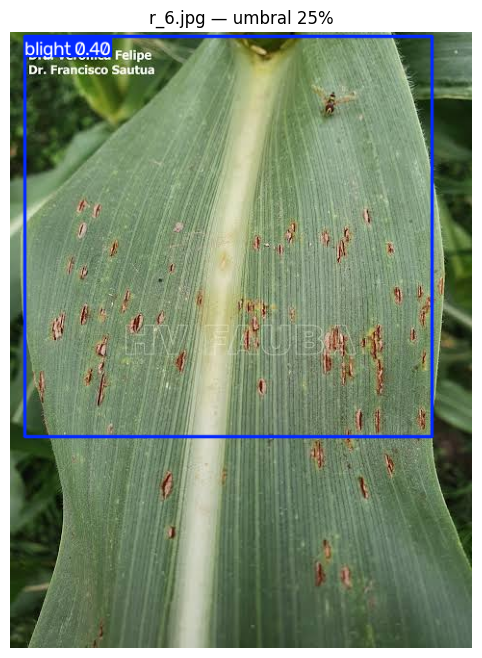

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Tizón foliar,39.92%,15.7,4.5,438.7,420.5



Analizando: r_5.jpg


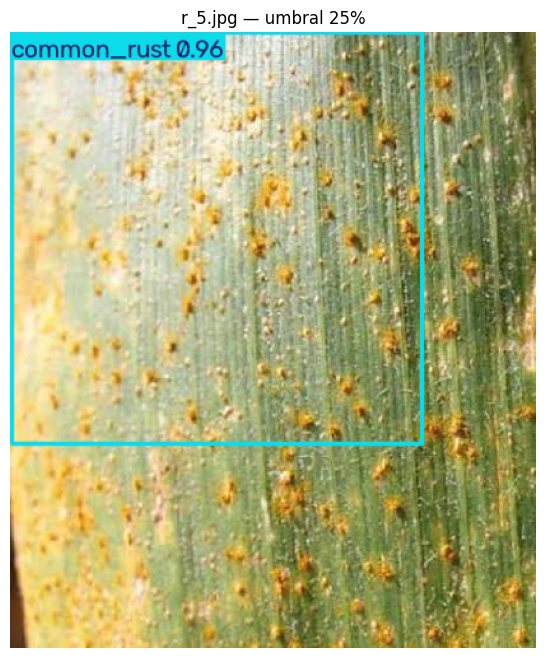

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Roya común,95.7%,1.1,0.4,323.9,323.2



Analizando: r_4.jpg


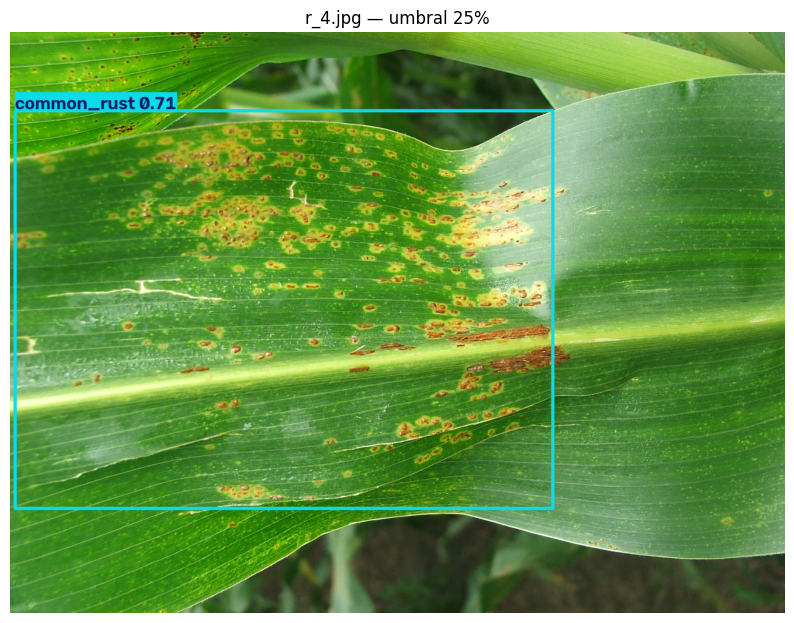

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Roya común,71.06%,8.4,131.5,896.4,787.8



Analizando: r_3.jpg


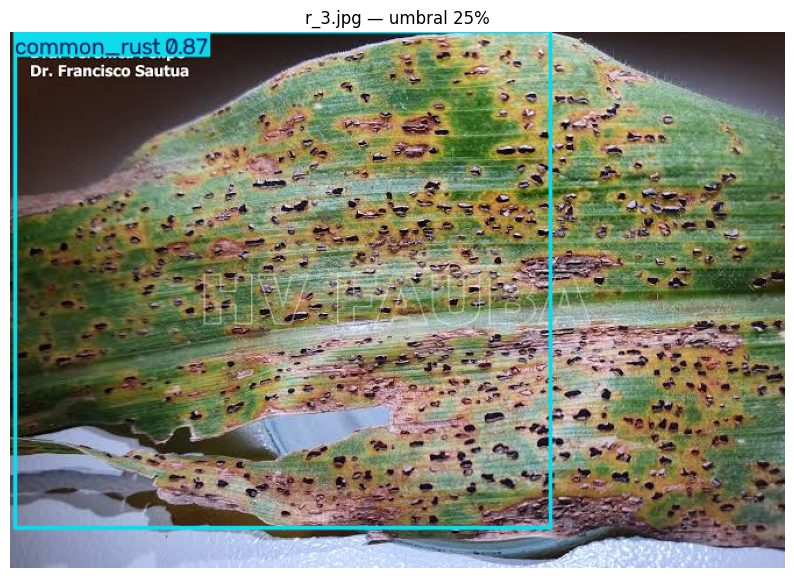

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Roya común,87.08%,4.5,0.3,464.7,426.5



Analizando: r_2.jpg


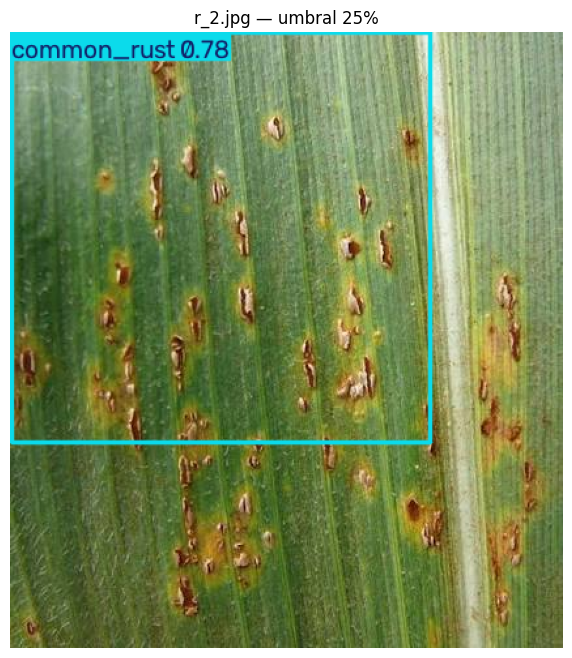

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Roya común,78.38%,1.9,0.2,321.0,314.9



Analizando: r_1.jpg


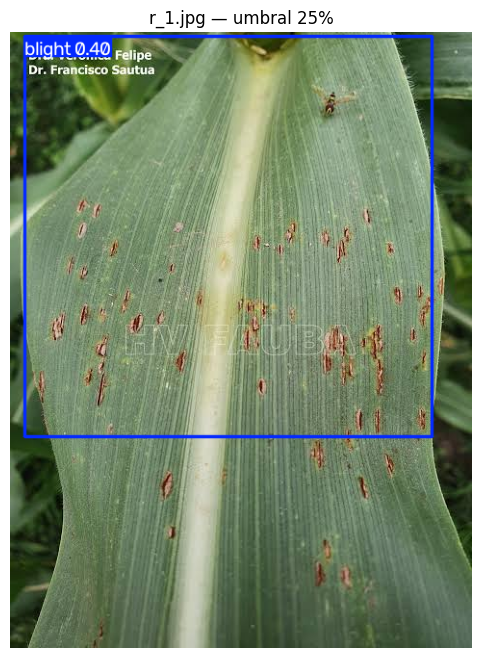

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Tizón foliar,39.92%,15.7,4.5,438.7,420.5



Analizando: tf_3.jpg


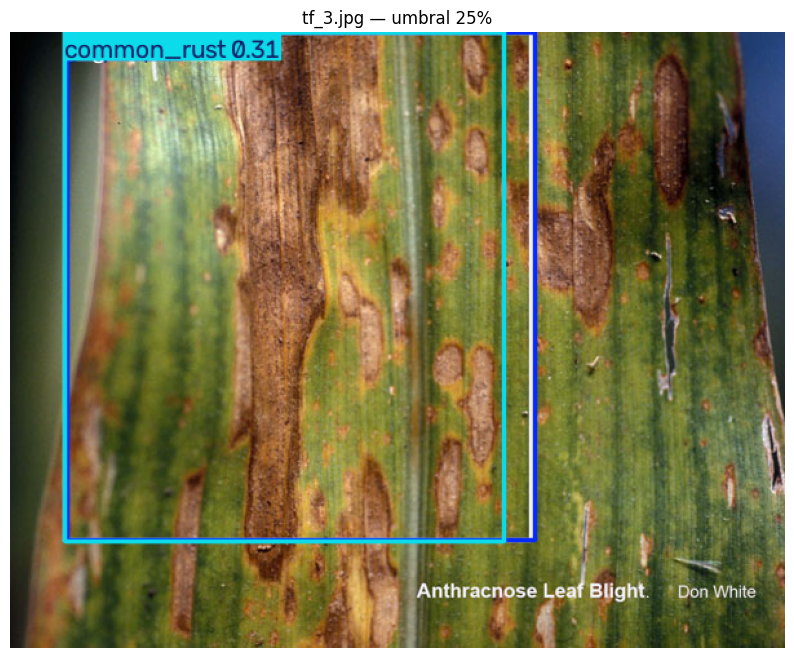

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Roya común,30.86%,42.8,0.0,382.6,395.0
1,2,Tizón foliar,28.38%,44.4,0.0,406.6,393.9
2,3,Mancha gris,25.97%,42.2,0.0,403.6,393.9



Analizando: tf_2.jpg


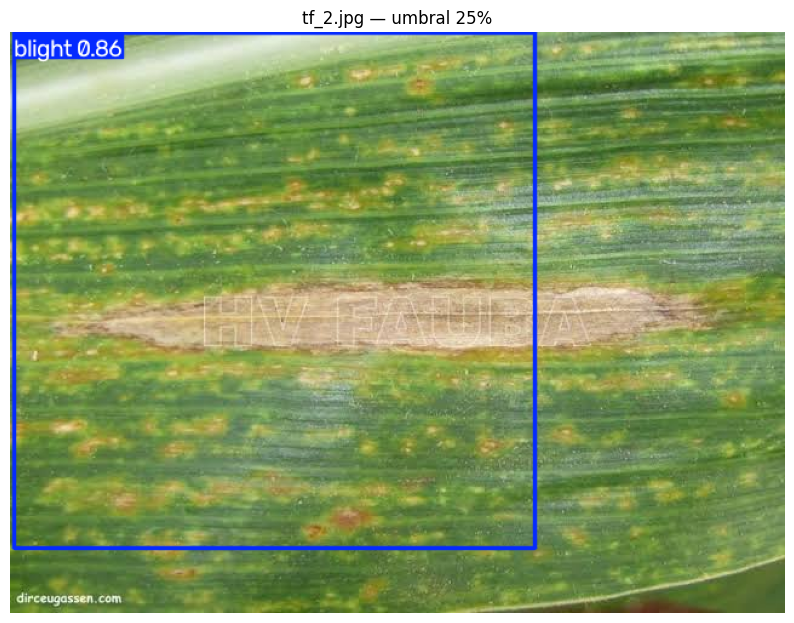

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Tizón foliar,85.96%,3.6,1.9,433.5,426.3



Analizando: tf_1.png


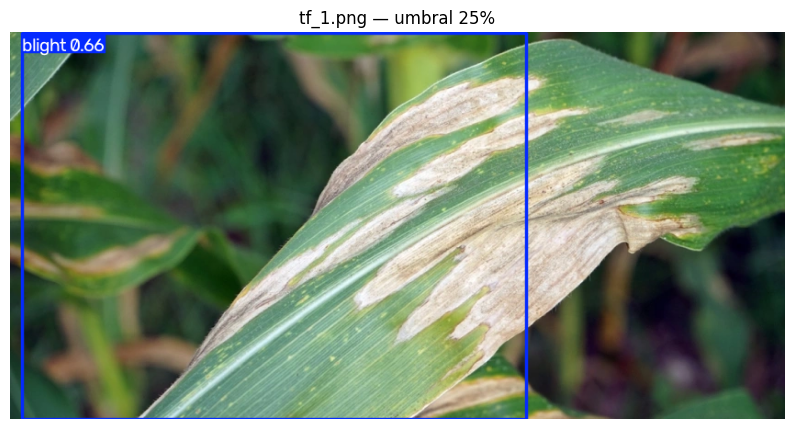

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Tizón foliar,66.12%,13.0,2.1,562.2,422.0



Analizando: mg_4 (1).jpg


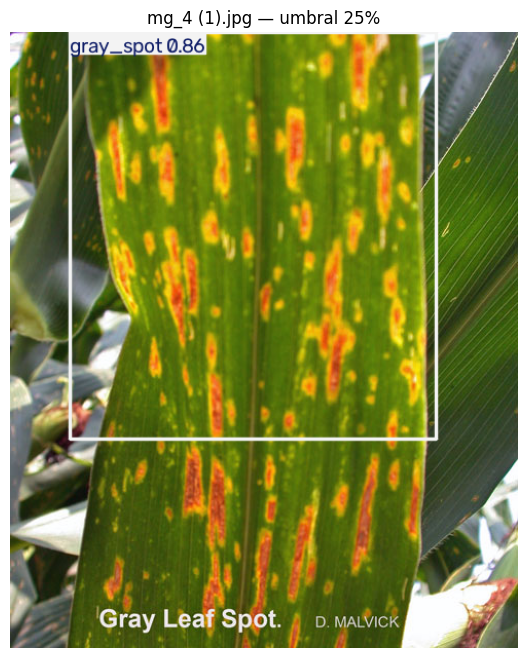

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Mancha gris,85.99%,59.0,0.6,414.7,396.4



Analizando: mg_3 (1).jpg


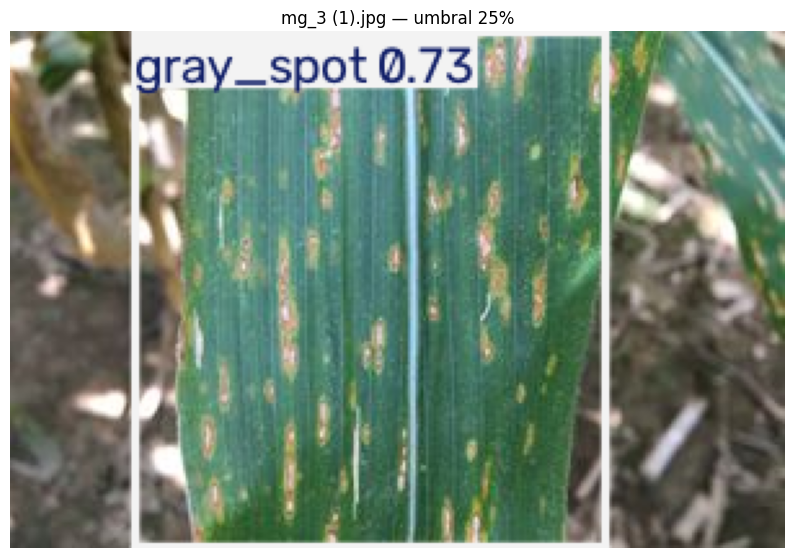

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Mancha gris,73.49%,48.2,0.0,230.5,200.0



Analizando: mg_2 (1).png


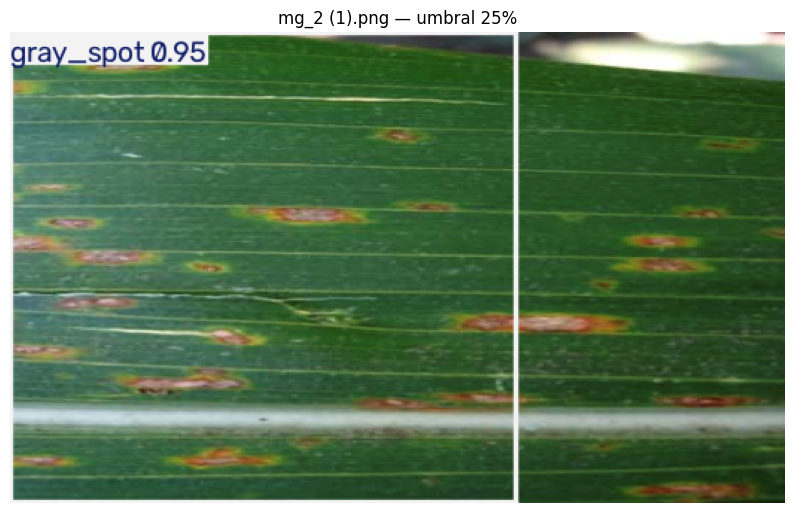

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Mancha gris,94.92%,0.0,0.3,339.6,315.3



Analizando: mg_1 (1).jpg


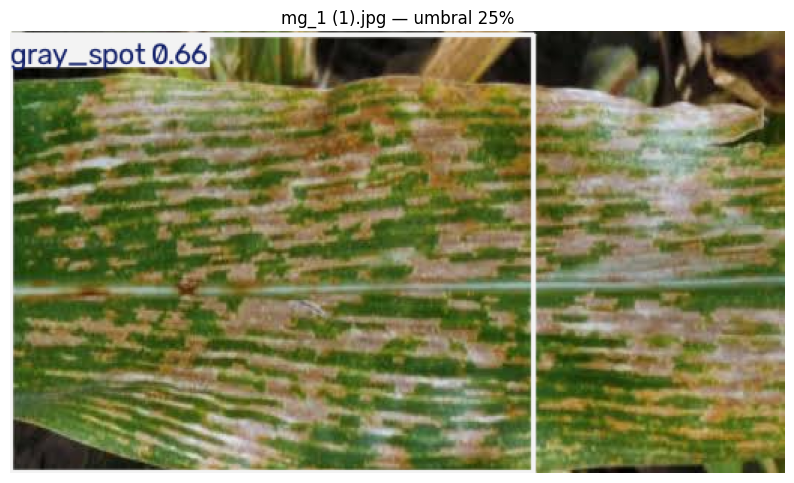

,deteccion,diagnostico,confianza,x1,y1,x2,y2
0,1,Mancha gris,65.77%,1.0,2.4,348.6,293.8




================ RESUMEN ================



,archivo,diagnostico_principal,confianza_principal,numero_detecciones,imagen_resultado
0,r_6.jpg,Tizón foliar,39.92,1,detectado_r_6.jpg
1,r_5.jpg,Roya común,95.70,1,detectado_r_5.jpg
2,r_4.jpg,Roya común,71.06,1,detectado_r_4.jpg
3,r_3.jpg,Roya común,87.08,1,detectado_r_3.jpg
4,r_2.jpg,Roya común,78.38,1,detectado_r_2.jpg
5,r_1.jpg,Tizón foliar,39.92,1,detectado_r_1.jpg
6,tf_3.jpg,Roya común,30.86,3,detectado_tf_3.jpg
7,tf_2.jpg,Tizón foliar,85.96,1,detectado_tf_2.jpg
8,tf_1.png,Tizón foliar,66.12,1,detectado_tf_1.jpg
9,mg_4 (1).jpg,Mancha gris,85.99,1,detectado_mg_4 (1).jpg


In [ ]:
SPANISH = {
    "blight": "Tizón foliar",
    "common_rust": "Roya común",
    "gray_spot": "Mancha gris",
    "health": "Hoja aparentemente sana",
}

OUTPUT_DIR = pathlib.Path(
    "/content/gafnet_resultados"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

all_rows = []
image_summaries = []

for image_path in image_paths:

    print("\n" + "=" * 80)
    print("Analizando:", image_path.name)
    print("=" * 80)

    results = model.predict(
        source=str(image_path),
        conf=CONFIDENCE,
        iou=IOU_THRESHOLD,
        imgsz=IMG_SIZE,
        verbose=False,
        save=False,
    )

    result = results[0]

    annotated_bgr = result.plot()
    annotated_rgb = cv2.cvtColor(
        annotated_bgr,
        cv2.COLOR_BGR2RGB
    )

    save_path = (
        OUTPUT_DIR
        / f"detectado_{image_path.stem}.jpg"
    )

    Image.fromarray(
        annotated_rgb
    ).save(
        save_path,
        quality=95
    )

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title(
        f"{image_path.name} — "
        f"umbral {CONFIDENCE:.0%}"
    )
    plt.show()

    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        print(
            "⚠️ No hubo detecciones por encima "
            "del umbral seleccionado."
        )

        image_summaries.append({
            "archivo": image_path.name,
            "diagnostico_principal":
                "Sin detecciones",
            "confianza_principal": np.nan,
            "numero_detecciones": 0,
            "imagen_resultado": save_path.name,
        })

        continue

    image_rows = []

    for detection_id, box in enumerate(
        boxes,
        start=1
    ):
        class_id = int(
            box.cls[0].item()
        )

        confidence = float(
            box.conf[0].item()
        )

        label = str(
            result.names[class_id]
        ).lower()

        xyxy = (
            box.xyxy[0]
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        row = {
            "archivo": image_path.name,
            "deteccion": detection_id,
            "clase_modelo": label,
            "diagnostico":
                SPANISH.get(label, label),
            "confianza": confidence,
            "x1": round(xyxy[0], 1),
            "y1": round(xyxy[1], 1),
            "x2": round(xyxy[2], 1),
            "y2": round(xyxy[3], 1),
            "umbral_confianza": CONFIDENCE,
            "imgsz": IMG_SIZE,
        }

        all_rows.append(row)
        image_rows.append(row)

    detection_df = pd.DataFrame(
        image_rows
    ).sort_values(
        "confianza",
        ascending=False
    )

    display_df = detection_df[
        [
            "deteccion",
            "diagnostico",
            "confianza",
            "x1",
            "y1",
            "x2",
            "y2",
        ]
    ].copy()

    display_df["confianza"] = (
        display_df["confianza"]
        * 100
    ).round(2).astype(str) + "%"

    display(display_df)

    # Priorizar enfermedad sobre health.
    disease_rows = detection_df[
        detection_df["clase_modelo"]
        != "health"
    ]

    if not disease_rows.empty:
        principal = disease_rows.iloc[0]
    else:
        principal = detection_df.iloc[0]

    image_summaries.append({
        "archivo":
            image_path.name,
        "diagnostico_principal":
            principal["diagnostico"],
        "confianza_principal":
            principal["confianza"],
        "numero_detecciones":
            len(detection_df),
        "imagen_resultado":
            save_path.name,
    })


details_df = pd.DataFrame(
    all_rows
)

summary_df = pd.DataFrame(
    image_summaries
)

print("\n\n================ RESUMEN ================\n")

if not summary_df.empty:
    resumen_visual = summary_df.copy()

    resumen_visual[
        "confianza_principal"
    ] = (
        resumen_visual[
            "confianza_principal"
        ]
        * 100
    ).round(2)

    display(resumen_visual)

## 8. Descargar resultados

Se generará un ZIP con:

- imágenes marcadas;
- resumen por fotografía;
- tabla de todas las detecciones.

In [ ]:
from google.colab import files

summary_csv = (
    OUTPUT_DIR
    / "resumen_diagnostico.csv"
)

details_csv = (
    OUTPUT_DIR
    / "detecciones_detalladas.csv"
)

summary_df.to_csv(
    summary_csv,
    index=False,
    encoding="utf-8-sig"
)

details_df.to_csv(
    details_csv,
    index=False,
    encoding="utf-8-sig"
)

ZIP_RESULTS = (
    "/content/resultados_GAFNet_maiz.zip"
)

shutil.make_archive(
    ZIP_RESULTS.replace(".zip", ""),
    "zip",
    OUTPUT_DIR
)

print(
    "✅ Resultados preparados:",
    ZIP_RESULTS
)

files.download(
    ZIP_RESULTS
)

✅ Resultados preparados: /content/resultados_GAFNet_maiz.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Recomendaciones para probar el modelo

Como ya hemos observado problemas de generalización con otros modelos, para evaluar GAF-Net conviene usar **exactamente las mismas fotografías**.

### Prueba sugerida

Ejecuta primero:

- confianza = `0.25`
- IoU = `0.70`
- imgsz = `640`

Después prueba las mismas imágenes con:

- `imgsz = 960`

Esto es especialmente útil si las lesiones son pequeñas.

### Qué mirar en la imagen marcada

No te fijes únicamente en el nombre de la enfermedad. Comprueba también si la caja está situada sobre:

- la lesión real;
- una zona sana;
- el fondo;
- bordes de la hoja;
- sombras;
- reflejos.

Si la caja se concentra sistemáticamente en regiones que no corresponden al síntoma, eso es evidencia visual de que el modelo tampoco está generalizando correctamente al dominio de sus fotografías.

### Limitación importante

El proyecto reporta en su propio conjunto de validación aproximadamente:

- Precision: 0.927
- Recall: 0.954
- mAP@50: 0.973
- mAP@50:0.95: 0.912

Las clases de validación fueron `blight`, `common_rust`, `gray_spot` y `health`.

Estas cifras **no deben interpretarse como precisión esperada en fotografías nuevas de campo**.